# 04 — Correlation Analysis
This notebook tests whether oil price spikes correlate with downstream 
inflation in key economies. We use World Bank CPI data to identify which 
countries historically absorb energy shocks vs. pass them to consumers.

**Input:** `outputs/master_prices.csv`, `data/API_FB.csv`  
**Output:** `outputs/inflation_correlation.csv`

## Imports & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load oil prices
master = pd.read_csv('../outputs/master_prices.csv', parse_dates=['date'])
master = master.set_index('date')

# Load World Bank inflation data - skip 4 metadata rows
inflation_raw = pd.read_csv('../data/API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_84.csv', skiprows=4)

print(inflation_raw.shape)
print(inflation_raw.columns[:8].tolist())

(266, 71)
['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963']


## Filter & Reshape
We filter to our key countries from the vulnerability analysis and reshape 
from wide format (years as columns) to long format (one row per country per year).

In [ ]:
# Countries we care about
countries = ['United States', 'Japan', 'China', 'India', 'Korea, Rep.', 'Pakistan', 'Taiwan, China', 'Germany', 'United Kingdom']

# Filter to relevant countries
inflation = inflation_raw[inflation_raw['Country Name'].isin(countries)].copy()

# Drop metadata columns we don't need
inflation = inflation.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code'])

# Drop uname columns
inflation = inflation.loc[:, ~inflation.columns.str.contains('Unnamed')]

# Reshape from wide to long
inflation = inflation.melt(id_vars='Country Name', var_name='year', value_name='inflation')
inflation['year'] = inflation['year'].astype(int)
inflation = inflation.dropna(subset=['inflation'])
inflation = inflation.sort_values(['Country Name', 'year']).reset_index(drop=True)

print(inflation['Country Name'].value_counts())
print(inflation.head(10))

Country Name
Germany           65
India             65
Japan             65
Korea, Rep.       65
Pakistan          65
United Kingdom    65
United States     65
China             38
Name: count, dtype: int64
  Country Name  year  inflation
0        China  1987   7.233836
1        China  1988  18.811818
2        China  1989  18.245638
3        China  1990   3.052290
4        China  1991   3.556686
5        China  1992   6.353981
6        China  1993  14.610079
7        China  1994  24.256990
8        China  1995  16.791225
9        China  1996   8.313160


## Build Annual Oil Price Series
We calculate the annual average Brent price and year-over-year % change 
to match the frequency of the World Bank inflation data.

In [ ]:
# Calculate annual average Brent price
annual_oil = master['brent'].resample('YE').mean().reset_index()
annual_oil.columns = ['date', 'brent_avg']
annual_oil['year'] = annual_oil['date'].dt.year
annual_oil['brent_yoy'] = annual_oil['brent_avg'].pct_change() * 100
annual_oil = annual_oil.dropna()

print(annual_oil.tail(10))

         date   brent_avg  year  brent_yoy
24 2017-12-31   54.208996  2017  24.068435
25 2018-12-31   71.111776  2018  31.180765
26 2019-12-31   64.314884  2019  -9.558040
27 2020-12-31   41.786023  2020 -35.029000
28 2021-12-31   70.849730  2021  69.553655
29 2022-12-31  100.893977  2022  42.405592
30 2023-12-31   82.450656  2023 -18.279902
31 2024-12-31   80.510654  2024  -2.352926
32 2025-12-31   69.075155  2025 -14.203709
33 2026-12-31   68.895952  2026  -0.259431


## Merge & Correlate
We merge annual oil price changes with inflation by year and calculate 
the correlation for each country. A high correlation means that country 
tends to pass energy price shocks through to consumers.

In [ ]:
# Merge oil and inflation on year

merged = pd.merge(inflation, annual_oil[['year', 'brent_yoy']], on='year', how='inner')

# Calculate correlation per country
correlations = merged.groupby('Country Name').apply(
    lambda x: x['brent_yoy'].corr(x['inflation'])
).reset_index()
correlations.columns = ['country', 'correlation']
correlations = correlations.sort_values('correlation', ascending=False).reset_index(drop=True)

print(correlations)

          country  correlation
0   United States     0.632544
1         Germany     0.284313
2  United Kingdom     0.252986
3     Korea, Rep.     0.063007
4           China     0.018479
5        Pakistan     0.011408
6           Japan    -0.147193
7           India    -0.243466


## Correlation Chart

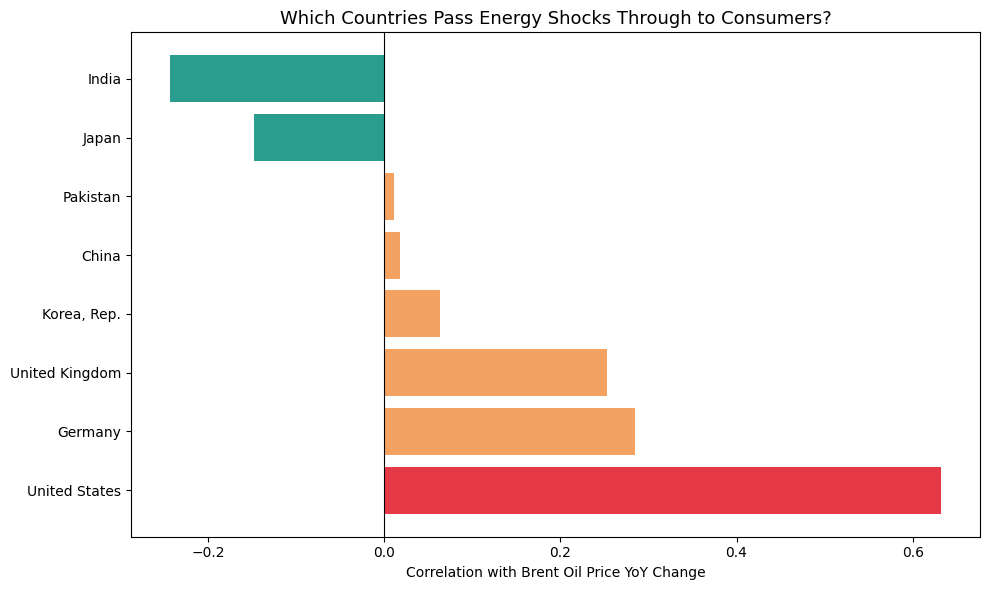

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#e63946' if c > 0.3 else '#f4a261' if c > 0 else '#2a9d8f' 
          for c in correlations['correlation']]

ax.barh(correlations['country'], correlations['correlation'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Correlation with Brent Oil Price YoY Change')
ax.set_title('Which Countries Pass Energy Shocks Through to Consumers?', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/inflation_correlation.png', dpi=150)
plt.show()

## Correlation Analysis

**Key findings:**

**United States (0.63)** — the strongest positive correlation despite being 
the least vulnerable country in our earlier analysis. This is counterintuitive 
but explainable — the US has a deregulated fuel market where pump prices 
move freely with crude, so oil shocks pass through directly to CPI.

**Germany & UK (0.25–0.28)** — moderate positive correlation. European 
markets pass through energy costs but heavy taxation and regulated energy 
markets act as a partial buffer.

**Korea, China, Pakistan (0.01–0.06)** — near zero correlation despite high 
vulnerability scores. These governments historically subsidize domestic fuel 
prices during shocks, absorbing the cost themselves rather than passing it 
to consumers. This masks their true economic exposure.

**Japan & India (negative)** — surprising negative correlation. Both countries 
have historically intervened heavily in energy markets during price spikes, 
and their inflation is often driven by other factors (food prices in India, 
deflation dynamics in Japan) that can move inversely to oil cycles.

**The key insight:** Vulnerability to supply disruption and vulnera

In [ ]:
correlations.to_csv('../outputs/inflation_correlation.csv', index=False)
print("Saved!")

Saved!
